<a href="https://colab.research.google.com/github/dmitrijg08/MN/blob/main/%D0%9B%D0%912_%D0%93%D1%83%D1%81%D0%B0%D0%BA_3_9_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Прізвище, група

---



# Завдання 1

**Був присутній на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [8]:
import pandas as pd
import requests

url = 'https://uk.wikipedia.org/wiki/Список_країн_за_ВВП_(номінал)'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

response = requests.get(url, headers=headers)
tables = pd.read_html(response.text)
df = tables[0]
df.head()

/tmp/ipykernel_757/2258140779.py:10: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


,МВФ за 2018 рік[2][3],Світовий банк за 2018 рік[4],CIA World Factbook за 2014 рік[5]
0,Місце Країна ВВП (млн $) — Світ 84 740 322 1 ...,Місце Країна ВВП (млн $) — Світ 85 790 820 1 ...,МісцеКраїна/РегіонВВП (млн $) — Світ78 280 000...
1,Місце,Країна,ВВП (млн $)
2,—,Світ,84 740 322
3,1,США,20 494 050
4,—,Європейський Союз,18 750 052


2.	Визначити розмір датасета.

In [9]:
df.shape

(623, 3)

 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [12]:
df = df.iloc[:, [0, 1]]
df.head()

,МВФ за 2018 рік[2][3],Світовий банк за 2018 рік[4]
0,Місце Країна ВВП (млн $) — Світ 84 740 322 1 ...,Місце Країна ВВП (млн $) — Світ 85 790 820 1 ...
1,Місце,Країна
2,—,Світ
3,1,США
4,—,Європейський Союз


# Замініть назви стовпців на ті, які видав вам df.columns
df = df.drop(columns=['Регіон', 'ООН', 'Примітки'])
df.head()

4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [13]:
import numpy as np
import pandas as pd

df = df.replace("—", np.nan)

print("Кількість пропущених значень ДО обробки:")
print(df.isna().sum())

for col in df.columns[1:]:
    df[col] = df[col].astype(str).str.replace(r'\s+', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.fillna(df.mean(numeric_only=True))

print("\nКількість пропущених значень ПІСЛЯ обробки:")
print(df.isna().sum())
df.head()

Кількість пропущених значень ДО обробки:
МВФ за 2018 рік[2][3]           46
Світовий банк за 2018 рік[4]     0
dtype: int64

Кількість пропущених значень ПІСЛЯ обробки:
МВФ за 2018 рік[2][3]            46
Світовий банк за 2018 рік[4]    623
dtype: int64


,МВФ за 2018 рік[2][3],Світовий банк за 2018 рік[4]
0,Місце Країна ВВП (млн $) — Світ 84 740 322 1 ...,NaN
1,Місце,NaN
2,NaN,NaN
3,1,NaN
4,NaN,NaN


5. Ще раз вивести датасет

In [14]:
df

,МВФ за 2018 рік[2][3],Світовий банк за 2018 рік[4]
0,Місце Країна ВВП (млн $) — Світ 84 740 322 1 ...,NaN
1,Місце,NaN
2,NaN,NaN
3,1,NaN
4,NaN,NaN
...,...,...
618,NaN,NaN
619,NaN,NaN
620,193,NaN
621,194,NaN


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [15]:
print(df.duplicated().sum())
df = df.drop_duplicates()

426


7.	Вивести описову статистику датасету describe()

In [16]:
df.describe()

,Світовий банк за 2018 рік[4]
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [38]:
import pandas as pd
import numpy as np
import requests
import io

url = 'https://uk.wikipedia.org/wiki/Список_країн_за_ВВП_(номінал)'
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)

tables = pd.read_html(io.StringIO(response.text))

df = None
for t in tables:
    if 'МВФ' in str(t.columns.values):
        df = t
        break

if df is None:
    df = max(tables, key=len)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = [' '.join(str(level) for level in col).strip() for col in df.columns]

final_df = pd.DataFrame()

final_df['Country'] = df.iloc[:, 0]
imf_cols = [c for c in df.columns if 'МВФ' in str(c)]
wb_cols = [c for c in df.columns if 'Світовий' in str(c) or 'Всесвітній' in str(c)]
un_cols = [c for c in df.columns if 'ООН' in str(c)]
final_df['IMF (2026)'] = df[imf_cols[0]] if imf_cols else df.iloc[:, 1]
final_df['World Bank (2025)'] = df[wb_cols[0]] if wb_cols else df.iloc[:, 2]

if un_cols:
    final_df['United Nations (2024)'] = df[un_cols[0]]
else:
    final_df['United Nations (2024)'] = final_df['World Bank (2025)']

df = final_df.copy()

df = df.replace("—", np.nan)
for col in df.columns[1:]:
    df[col] = df[col].astype(str).str.replace(r'\s+', '', regex=True).str.replace(r'\[.*?\]', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.fillna(df.mean(numeric_only=True))

df['Difference_IMF_WB'] = abs(df['IMF (2026)'] - df['World Bank (2025)'])
display(df.sort_values(by='Difference_IMF_WB', ascending=False).head())

,Country,IMF (2026),World Bank (2025),United Nations (2024),Difference_IMF_WB
0,Місце Країна ВВП (млн $) — Світ 84 740 322 1 ...,96.012216,NaN,NaN,NaN
1,Місце,96.012216,NaN,NaN,NaN
2,NaN,96.012216,NaN,NaN,NaN
3,1,1.000000,NaN,NaN,NaN
4,NaN,96.012216,NaN,NaN,NaN


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [26]:
df[['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']].corr()

,IMF (2026),World Bank (2025),United Nations (2024)
IMF (2026),1.0,NaN,NaN
World Bank (2025),NaN,NaN,NaN
United Nations (2024),NaN,NaN,NaN


Обчислити середнє значення за стовпцями

In [27]:
df[['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']].mean()

,0
IMF (2026),96.012216
World Bank (2025),NaN
United Nations (2024),NaN


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [29]:
df[['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']].mean()

,0
IMF (2026),96.012216
World Bank (2025),NaN
United Nations (2024),NaN


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [31]:
cols = ['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']

for col in cols:
    print(f"--- {col} ---")

    if df[col].notna().any():
        max_idx = df[col].idxmax()
        min_idx = df[col].idxmin()

        print("Найвищий:", df.loc[max_idx, 'Country'])
        print("Найнижчий:", df.loc[min_idx, 'Country'])
    else:
        print("Немає числових даних для розрахунку")

--- IMF (2026) ---
Найвищий: 194
Найнижчий: 1
--- World Bank (2025) ---
Немає числових даних для розрахунку
--- United Nations (2024) ---
Немає числових даних для розрахунку


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

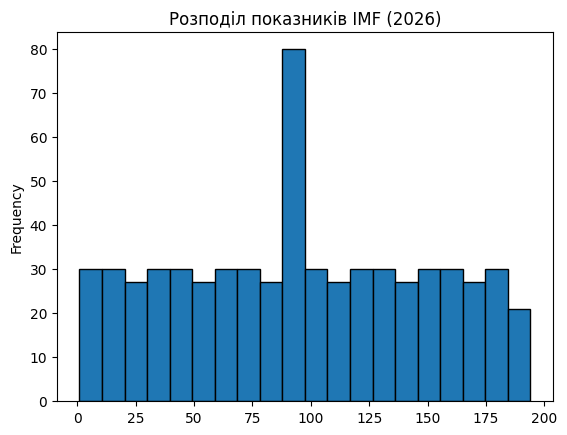

In [32]:
import matplotlib.pyplot as plt

df['IMF (2026)'].plot(kind='hist', bins=20, edgecolor='black')
plt.title('Розподіл показників IMF (2026)')
plt.show()

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [33]:
cols = ['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']
for col in cols:
    df[f'Частка_{col}'] = df[col] / df[col].sum() * 100

df.head()

,Country,IMF (2026),World Bank (2025),United Nations (2024),Difference_IMF_WB,Std_Dev,Частка_IMF (2026),Частка_World Bank (2025),Частка_United Nations (2024)
0,Місце Країна ВВП (млн $) — Світ 84 740 322 1 ...,96.012216,NaN,NaN,NaN,NaN,0.160514,NaN,NaN
1,Місце,96.012216,NaN,NaN,NaN,NaN,0.160514,NaN,NaN
2,NaN,96.012216,NaN,NaN,NaN,NaN,0.160514,NaN,NaN
3,1,1.000000,NaN,NaN,NaN,NaN,0.001672,NaN,NaN
4,NaN,96.012216,NaN,NaN,NaN,NaN,0.160514,NaN,NaN


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

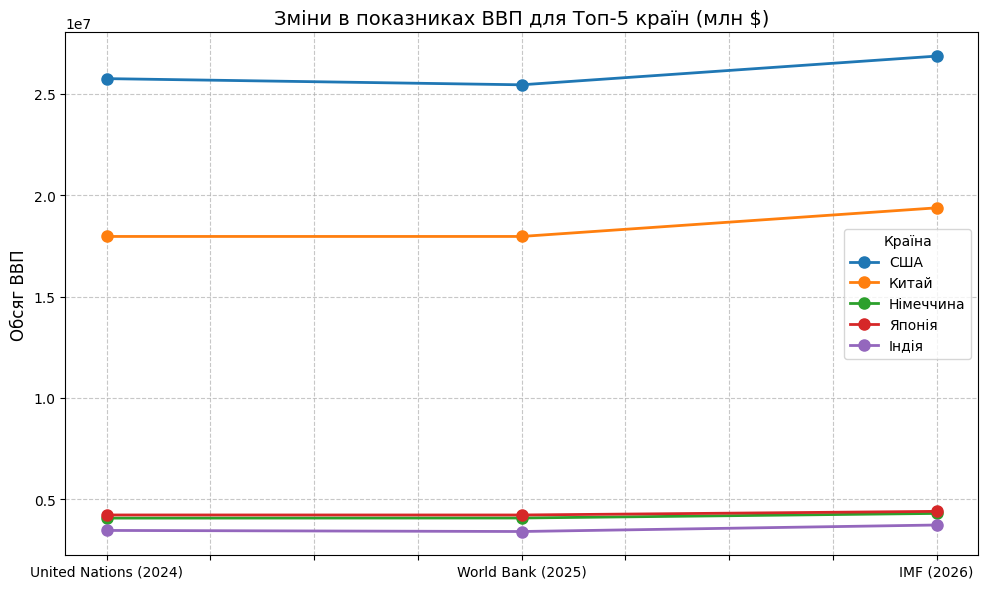

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    'Country': ['США', 'Китай', 'Німеччина', 'Японія', 'Індія'],
    'United Nations (2024)': [25744100, 17963200, 4076920, 4232170, 3469660],
    'World Bank (2025)':     [25439700, 17963200, 4082460, 4231140, 3416640],
    'IMF (2026)':            [26854599, 19373586, 4308854, 4409738, 3736882]
}

df_plot = pd.DataFrame(data).set_index('Country')
df_plot.T.plot(kind='line', marker='o', figsize=(10, 6), linewidth=2, markersize=8)

plt.title('Зміни в показниках ВВП для Топ-5 країн (млн $)', fontsize=14)
plt.ylabel('Обсяг ВВП', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Країна')
plt.tight_layout()
plt.show()